## Importando Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('netflix_titles_sujo.csv')

In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Análise Exploratória de Dados (EDA)

In [13]:
# Verificando as informações gerais do DataFrame
print("\n--- Informações Gerais do DataFrame \n")
df.info()


--- Informações Gerais do DataFrame 

<class 'pandas.DataFrame'>
RangeIndex: 8812 entries, 0 to 8811
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8812 non-null   str  
 1   type          8812 non-null   str  
 2   title         8812 non-null   str  
 3   director      6174 non-null   str  
 4   cast          7985 non-null   str  
 5   country       7979 non-null   str  
 6   date_added    8802 non-null   str  
 7   release_year  8812 non-null   str  
 8   rating        8807 non-null   str  
 9   duration      8809 non-null   str  
 10  listed_in     8812 non-null   str  
 11  description   8812 non-null   str  
dtypes: str(12)
memory usage: 3.9 MB


In [14]:
print("\n--- Verificando valores ausentes ---\n")
print(df.isna().sum())


--- Verificando valores ausentes ---

show_id            0
type               0
title              0
director        2638
cast             827
country          833
date_added        10
release_year       0
rating             5
duration           3
listed_in          0
description        0
dtype: int64


In [15]:
print("\n--- Verificando a presença de registros duplicados ---\n")
print(f"Número de linhas duplicadas: {df.duplicated().sum()}")


--- Verificando a presença de registros duplicados ---

Número de linhas duplicadas: 5


In [16]:
print("\n--- Estatísticas descritivas para colunas categóricas ---\n")
print(df.describe(include = [str]))


--- Estatísticas descritivas para colunas categóricas ---

       show_id   type                 title       director  \
count     8812   8812                  8812           6174   
unique    8807      2                  8807           4527   
top         s1  Movie  Dick Johnson Is Dead  Rajiv Chilaka   
freq         2   6132                     2             19   

                      cast        country       date_added release_year  \
count                 7985           7979             8802         8812   
unique                7692            748             1767           77   
top     David Attenborough  United States  January 1, 2020         2018   
freq                    19           2819              109         1147   

       rating  duration                     listed_in  \
count    8807      8809                          8812   
unique     17       220                           514   
top     TV-MA  1 Season  Dramas, International Movies   
freq     3211      1795  

In [17]:
# Verificando as informações gerais do DataFrame
print("\n--- Tipos de dados ---\n")
df.dtypes


--- Tipos de dados ---



show_id         str
type            str
title           str
director        str
cast            str
country         str
date_added      str
release_year    str
rating          str
duration        str
listed_in       str
description     str
dtype: object

## Limpeza e Pré-Processamento dos Dados

#### Convertendo campo "release_year" para tipo correto

In [18]:
df = pd.read_csv('netflix_titles_sujo.csv')
df_copia = df.copy()

In [19]:
# Convertendo 'release_year' para númerico, tratando erros
df_copia['release_year'] = pd.to_numeric(df_copia['release_year'], errors = 'coerce').astype('Int64')

In [20]:
df_copia['release_year'].dtype

Int64Dtype()

#### Identificando colunas com valores ausentes e preenchendo 

In [21]:
print(df_copia.isna().sum())

show_id            0
type               0
title              0
director        2638
cast             827
country          833
date_added        10
release_year       2
rating             5
duration           3
listed_in          0
description        0
dtype: int64


In [23]:
# Preechendo apenas as colunas com type "str" com valor "Não Informado"
colunas_texto = df_copia.select_dtypes(include='str').columns

df_copia[colunas_texto] = df_copia[colunas_texto].fillna('Não Informado')

In [24]:
print(df_copia.isna().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    2
rating          0
duration        0
listed_in       0
description     0
dtype: int64


#### Identificar linhas duplicadas e realizar a exclusão

In [29]:
# Identificando a quantidade de duplicadas
df_copia.duplicated().sum()

np.int64(5)

In [30]:
# Exibindo as duplicadas
df_copia[df_copia.duplicated(keep=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Não Informado,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Não Informado,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,Não Informado,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Não Informado,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
8807,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Não Informado,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
8808,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
8809,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Não Informado,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
8810,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,Não Informado,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
8811,s5,TV Show,Kota Factory,Não Informado,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [33]:
# Removendo linhas duplicadas
df_copia = df_copia.drop_duplicates()

In [32]:
df_copia.duplicated().sum()

np.int64(0)

#### Analisando Outliers

In [36]:
# Identificando Outliers
df_copia['release_year'].describe()

count         8804.0
mean     2014.177874
std         8.819916
min           1925.0
25%           2013.0
50%           2017.0
75%           2019.0
max           2021.0
Name: release_year, dtype: Float64

In [35]:
# Corrigindo valor descrepante
df_copia.loc[df_copia['release_year'] > 2025, 'release_year'] = pd.NA

## Engenharia de Atributos e Extração de Insights

In [43]:
# Verificando dataset limpo
df_copia.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Não Informado,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Não Informado,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,Não Informado,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Não Informado,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [47]:
# Quantidade total de filmes e séries
filmes_total = df_copia['title'].count()
print(f"A Quantidade total de Filmes e Séries é: {filmes_total}")

A Quantidade total de Filmes e Séries é: 8807


In [48]:
df_copia['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     589
Name: count, Length: 74, dtype: Int64

## Visualização dos Dados e Análise

#### Gráfico 1

In [49]:
# Faz o agrupamento pelo ano de lançamento utilizando a coluna 'release_year'
# .size() faz a contagem de linhas
# .sort_index() coloca os anos em ordem crescente

titulos_por_ano = df_copia.groupby('release_year').size().sort_index()

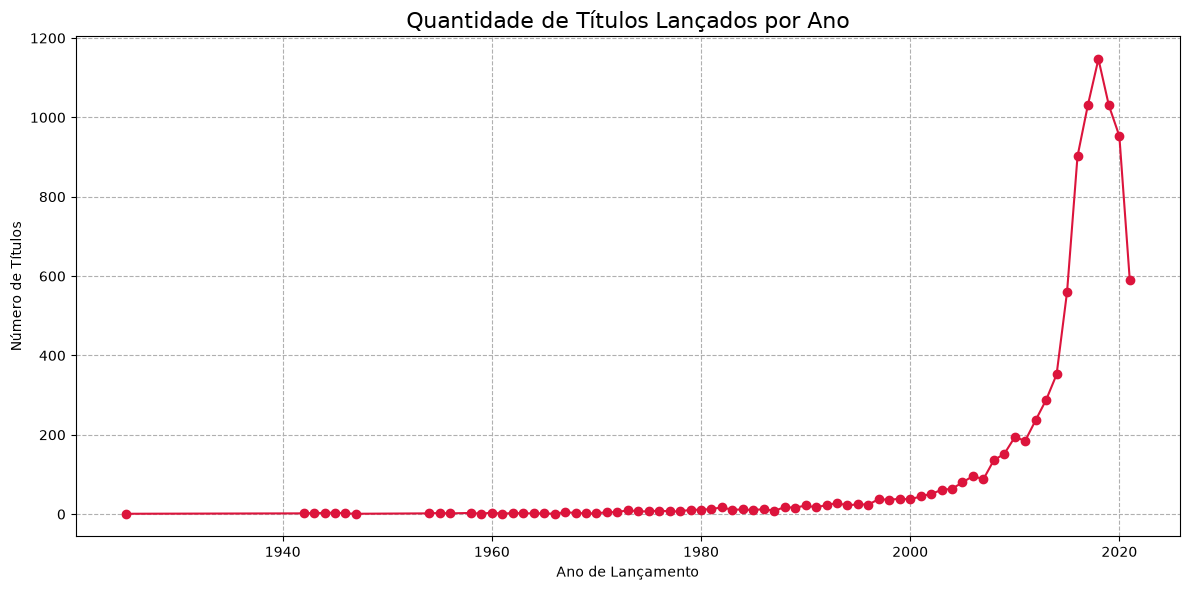

In [50]:
# Criando gráfico de linha
# figsize define o tamanho do gráfico
plt.figure(figsize=(12,6))
plt.plot(titulos_por_ano.index, titulos_por_ano.values, marker='o', color='crimson')

# Definindo titulo do grafico e nomes dos eixos(x,y)
plt.title('Quantidade de Títulos Lançados por Ano', fontsize=16)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Títulos')

# Personalizando grafico
# .grid adiciona uma grade
# .tight_layout() ajusta automaticamente o espaçamento do grafico
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#### Gráfico 2

In [56]:
# Realiza a contagem da quantidade de cada tipo

Contagem_Tipos = df['type'].value_counts()
Contagem_Tipos

type
Movie      6132
TV Show    2680
Name: count, dtype: int64

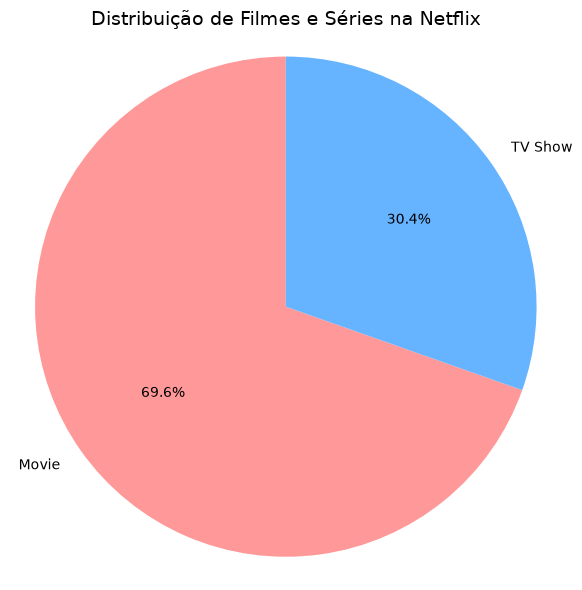

In [57]:
# autopct exibi os dados em porcentagem com uma casa decimal
#startangle começa com grafico pelo topo
plt.figure(figsize=(6,6))
plt.pie(Contagem_Tipos, labels=Contagem_Tipos.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])

plt.title('Distribuição de Filmes e Séries na Netflix', fontsize=14)

# Deixa o gráfico redondo
plt.axis('equal')  
plt.tight_layout()
plt.show()